# Лабораторная работа 6. Понижение размерности. Задача регрессии

In [75]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error


data = pd.read_csv('datasets/air.csv', index_col=0)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,day_of_week,hour,year
0,0.211864,0.511845,0.226923,0.408251,0.118241,0.493333,0.513040,0.455614,0.333333,0.499371,0.280066,0.3,3,3,18,2004
1,0.161017,0.463029,0.178846,0.352217,0.072819,0.400000,0.453237,0.326806,0.326882,0.484277,0.264282,0.3,3,3,19,2004
2,0.177966,0.541996,0.171154,0.342365,0.093006,0.497778,0.451439,0.371192,0.296774,0.563522,0.276352,0.3,3,3,20,2004
3,0.177966,0.523331,0.175000,0.347906,0.122567,0.533333,0.464478,0.427328,0.277419,0.638994,0.294190,0.3,3,3,21,2004
4,0.127119,0.448672,0.123077,0.278941,0.093006,0.506667,0.422212,0.386858,0.281720,0.633962,0.295216,0.3,3,3,22,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,0.254237,0.478823,0.257692,0.442118,0.338861,0.835556,0.370054,0.656223,0.511828,0.252830,0.279578,0.1,4,1,10,2005
9353,0.194915,0.370424,0.217308,0.396552,0.253064,0.786667,0.320594,0.456049,0.563441,0.182390,0.257636,0.1,4,1,11,2005
9354,0.194915,0.355348,0.236538,0.418719,0.209805,0.768889,0.310252,0.379025,0.619355,0.114465,0.222792,0.1,4,1,12,2005
9355,0.169492,0.255564,0.180769,0.355911,0.167988,0.684444,0.220324,0.238903,0.649462,0.054088,0.160876,0.1,4,1,13,2005


In [76]:
X, y = data.drop("CO(GT)", axis=1), data["CO(GT)"]

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
metrics = ["R2", "MSE", "RMSE", "MAE"]
columns = [type_of_data + " " + metric for type_of_data in ["Train", "Test"] for metric in metrics]
table = pd.DataFrame(columns=columns)


def get_scores(X, y, model):
    r2 = round(r2_score(y, model.predict(X)), 2)
    mse = round(mean_squared_error(y, model.predict(X)), 4)
    rmse = round(root_mean_squared_error(y, model.predict(X)), 4)
    mae = round(mean_absolute_error(y, model.predict(X)), 4)
    return r2, mse, rmse, mae

def input_into_table(X_train, X_test, y_train, y_test, model, name):
    train_scores = get_scores(X_train, y_train, model)
    test_scores = get_scores(X_test, y_test, model)

    table.loc[name] = train_scores + test_scores

## Понижение размерности

### VarianceThreshold

Для того, чтобы понять, какой порог дисперсии использовать для отбора признаков, построим графики дисперсии по каждому признаку.

C:\Users\79585\AppData\Local\Temp\ipykernel_7264\184370451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variances.index, y=variances.values, palette='viridis')


Text(0, 0.5, 'Variance')

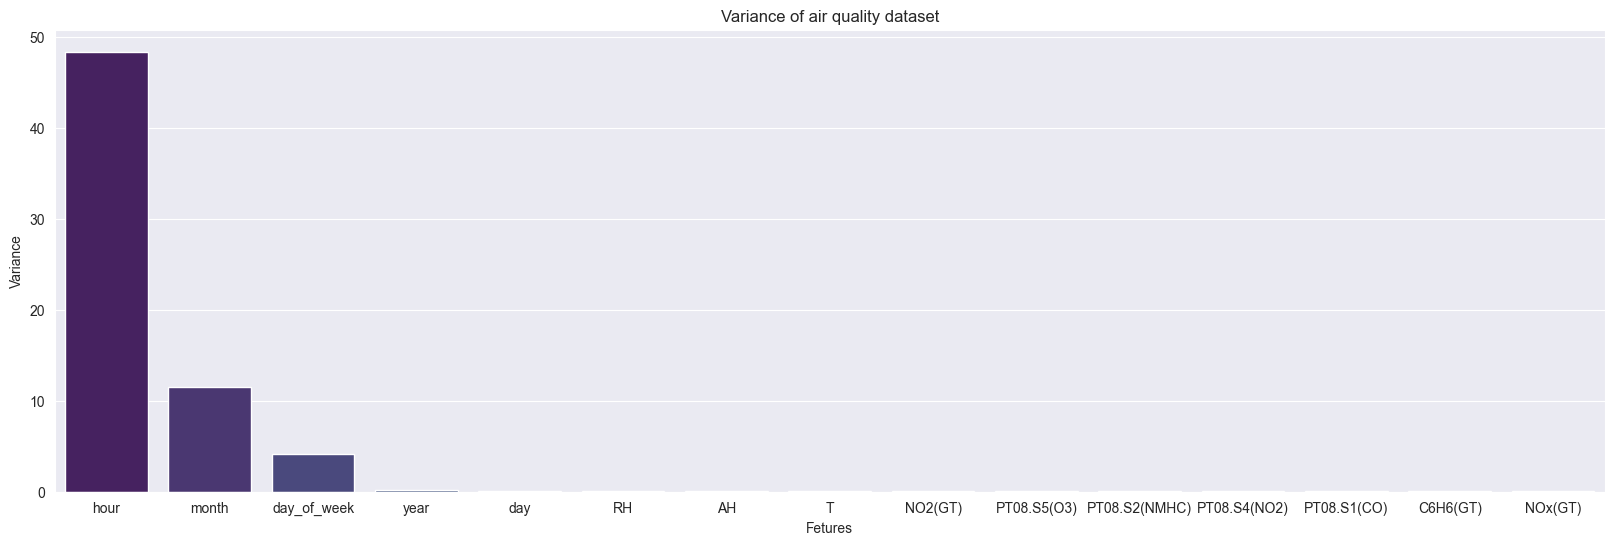

In [79]:
from matplotlib import pyplot as plt
import seaborn as sns

variances = X_train.var().sort_values(ascending=False)


plt.figure(figsize=(20, 6))
sns.barplot(x=variances.index, y=variances.values, palette='viridis')
plt.title("Variance of air quality dataset")
plt.xlabel("Fetures")
plt.ylabel("Variance")

Дисперсии временных рядов велики, так как они были закодированы как категориальные и не были масштабированы. Не будем их учитывать при анализе дисперсий.

C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2126914670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variances.index, y=variances.values, palette='viridis')


Text(0, 0.5, 'Variance')

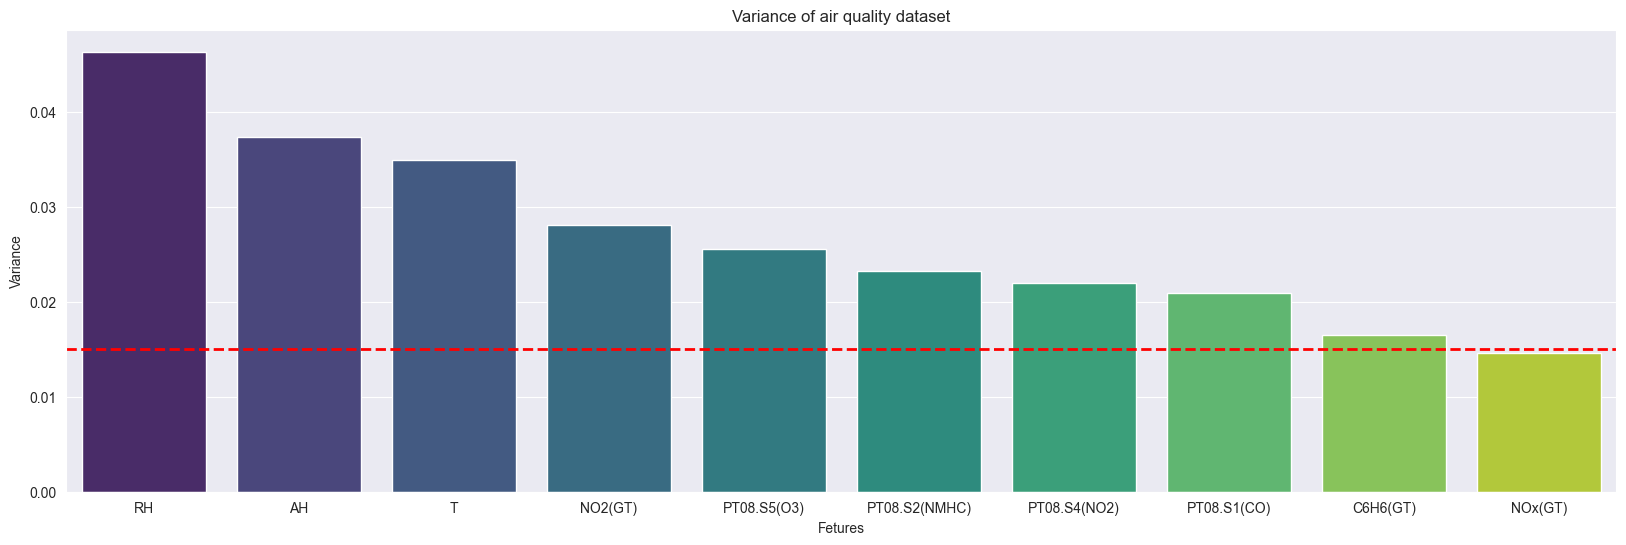

In [80]:
variances = X_train.drop(["hour", "month", "day_of_week", "year", "day"], axis=1).var().sort_values(ascending=False)


plt.figure(figsize=(20, 6))
sns.barplot(x=variances.index, y=variances.values, palette='viridis')
plt.title("Variance of air quality dataset")
plt.axhline(y=0.015, color='red', linestyle='--', linewidth=2, label='Порог 0.015')
plt.xlabel("Fetures")
plt.ylabel("Variance")

Видим, что среди признаков нет предикторов с низкой дисперсией. Это говорит о том, что этот способ оптимизации признакового пространства не совсем подходит для этих данных. В рамках эксперимента попробуем использовать порог 0.015.

In [81]:
from sklearn.feature_selection import VarianceThreshold

selector_vt = VarianceThreshold(threshold=0.015)
X_vt = selector_vt.fit_transform(X_train)

selected_features = X_train.columns[selector_vt.get_support()]
print(f"Исходная размерность: {len(X_train.columns)}, оптимизированная размерность: {len(selected_features)}")
print("Отобранные признаки: ")
print(selected_features.tolist())

Исходная размерность: 15, оптимизированная размерность: 14
Отобранные признаки: 
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'day_of_week', 'hour', 'year']


Видим, что признаковое пространство сократилось на единицу - признак NOx(GT) был убран.

Этот спобос не совсем эффективен для этих данных, так как, как было выяснено в предыдущий лабораторных работах, признак NOx(GT) был важным предиктором для ансамблевых моделей.

Попробуем обучить модель на оптимизированных данных.

In [82]:
from catboost import CatBoostRegressor
best_params = {
    'iterations': 500,
    'learning_rate': 0.06771823320433545,
    'depth': 8,
    'l2_leaf_reg': 3,
    'verbose': False,
    'random_seed': 42
}
X_test_vet = selector_vt.transform(X_test)
model = CatBoostRegressor(**best_params)
model.fit(X_vt, y_train)
input_into_table(X_vt, X_test_vet, y_train, y_test, model, name="VarianceThreshold")
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186


Text(0.5, 0.98, 'VarianceThreshold')

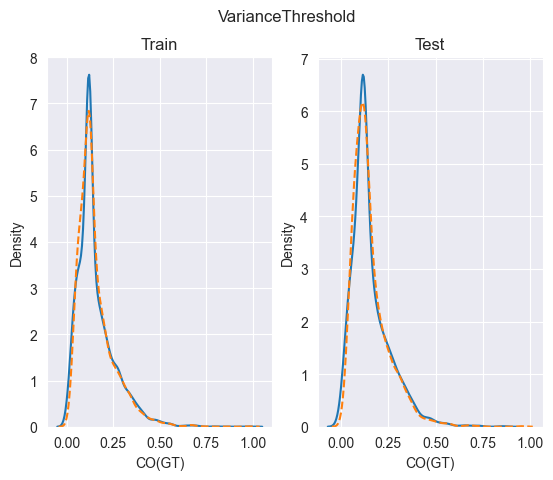

In [83]:
train_prediction = model.predict(X_vt)
test_prediction = model.predict(X_test_vet)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("VarianceThreshold")

### SelectKBest

C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2596820632.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(feature_importance, x="Features", y="Importance", palette='Set1')


<Axes: xlabel='Features', ylabel='Importance'>

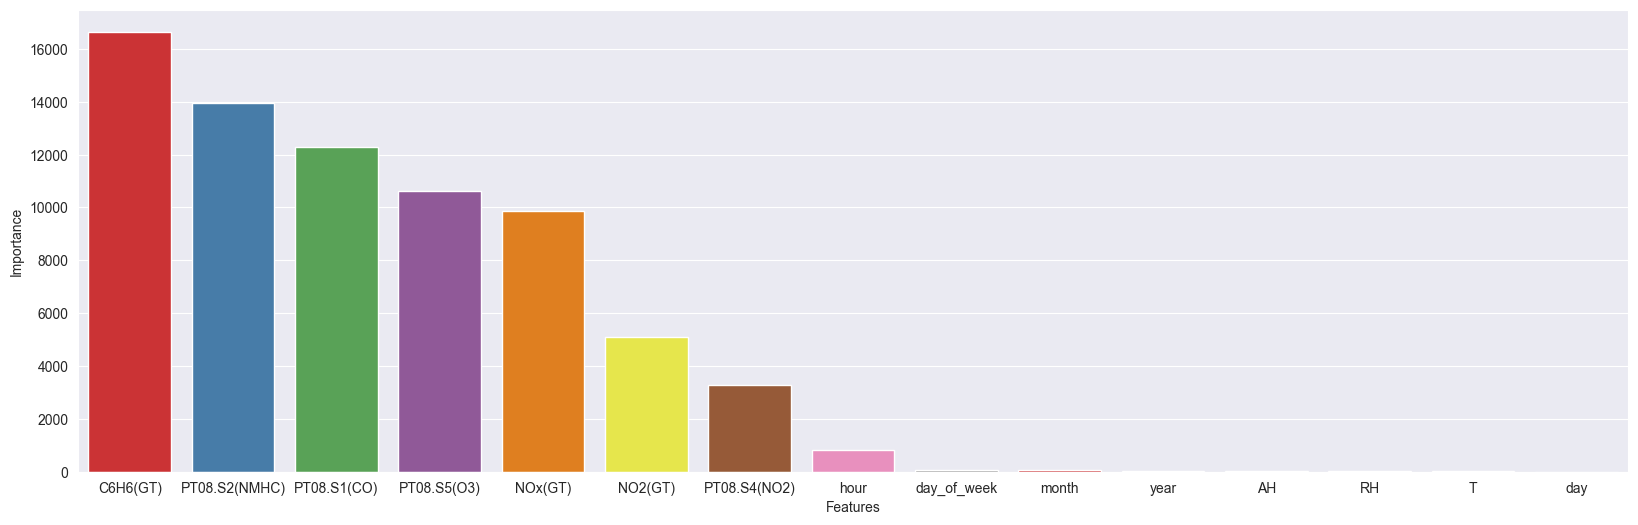

In [84]:
from sklearn.feature_selection import SelectKBest, f_regression

selector_skb = SelectKBest(score_func=f_regression, k=5)

selected_features_skb = selector_skb.fit_transform(X_train, y_train)

feature_importance = pd.DataFrame({"Features": X_train.columns, "Importance": selector_skb.scores_})
feature_importance.sort_values("Importance", ascending=False, inplace=True)
plt.figure(figsize=(20, 6))
sns.barplot(feature_importance, x="Features", y="Importance", palette='Set1')

In [85]:
X.columns[selector_skb.get_support()]

Index(['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S5(O3)'], dtype='str')

SelectKBest отработал значительно лучше: он отобрал только признаки с датчиков, собирающих информацию о содержании хим. веществ в воздухе.

In [86]:
X_train_skb = selector_skb.transform(X_train)
X_test_skb = selector_skb.transform(X_test)
model = CatBoostRegressor(**best_params)
model.fit(X_train_skb, y_train)
input_into_table(X_train_skb, X_test_skb, y_train, y_test, model, name="SelectKBest")
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260


Text(0.5, 0.98, 'SelectKBest')

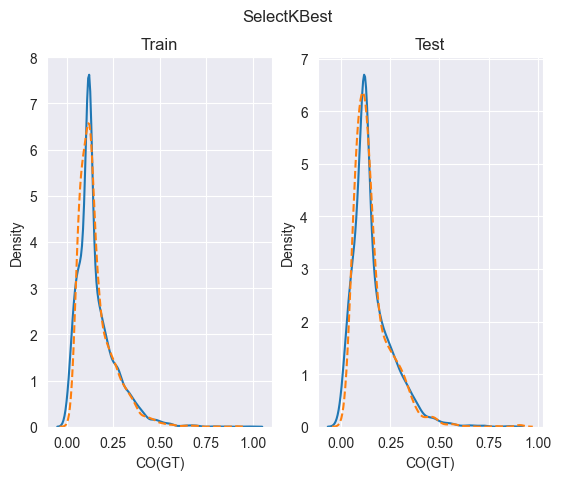

In [87]:
train_prediction = model.predict(X_train_skb)
test_prediction = model.predict(X_test_skb)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("SelectKBest")

### RFE

C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2631076511.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=rfe_data, palette='viridis')


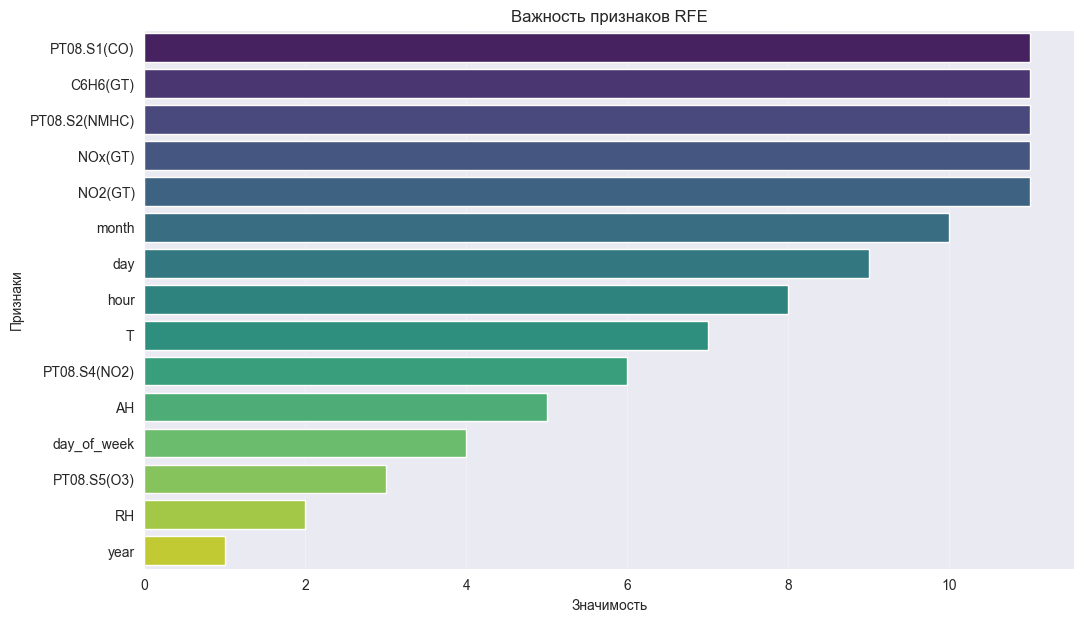

In [88]:
from sklearn.feature_selection import RFE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = CatBoostRegressor(**best_params)
selector_rfe = RFE(estimator=model, n_features_to_select=5, step=1)

selected_features = selector_rfe.fit_transform(X_train, y_train)

rfe_data = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': selector_rfe.ranking_
})


rfe_data['Importance_Score'] = rfe_data['Rank'].max() - rfe_data['Rank'] + 1
rfe_data = rfe_data.sort_values('Importance_Score', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(x='Importance_Score', y='Feature', data=rfe_data, palette='viridis')

plt.title('Важность признаков RFE')
plt.xlabel('Значимость')
plt.ylabel('Признаки')
plt.grid(axis='x', alpha=0.3)
plt.show()


Наиболее важными признаками алгоритм RFE посчитал некоторые показания датчиков, как и предыдущий алгоритм понижения размерности SelectKBest.

In [89]:
chosen_features = X_train.columns[selector_rfe.get_support()].tolist()

print(f"Выбранные признаки: {chosen_features}")

Выбранные признаки: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)']


In [90]:
X_train_rfe = selector_rfe.transform(X_train)
X_test_rfe = selector_rfe.transform(X_test)
model = CatBoostRegressor(**best_params)
model.fit(X_train_rfe, y_train)
input_into_table(X_train_rfe, X_test_rfe, y_train, y_test, model, name="RFE")
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252


Text(0.5, 0.98, 'RFE')

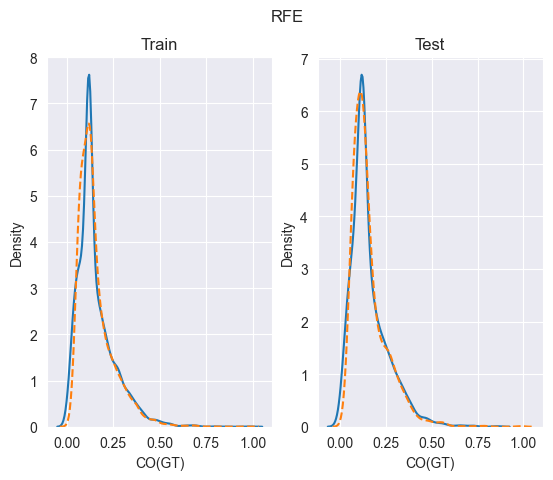

In [91]:
train_prediction = model.predict(X_train_rfe)
test_prediction = model.predict(X_test_rfe)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("RFE")

### PCA

Попробуем для начала сократить размерность до 5.

In [92]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)

print(f"Размерность до PCA: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

exp_var = pca.explained_variance_ratio_

Размерность до PCA: 15
Размерность после PCA: 5


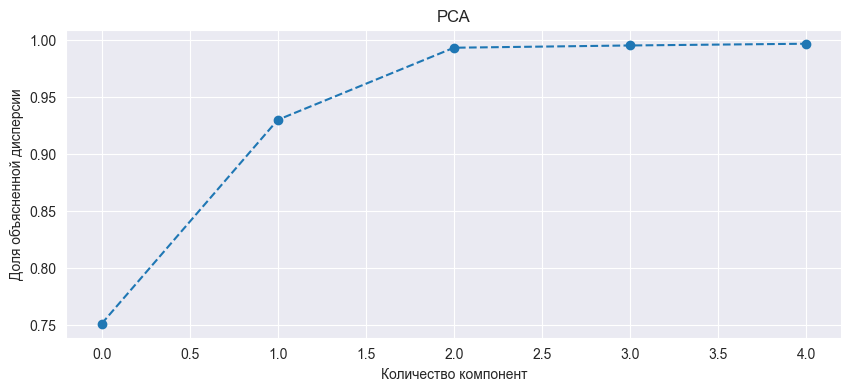

In [93]:
import numpy as np

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('РСА')
plt.xlabel('Количество компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.show()


Видим, что доля объясненной дисперсии уже при 3 компонентах объясняет 100 процентов информации. Сократим количество компонент с 5 до 3.

In [94]:
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train)

print(f"Размерность до PCA: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

Размерность до PCA: 15
Размерность после PCA: 3


In [95]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_train.columns
)

print("Вклад исходных признаков в каждую компоненту:")
print(loadings)

Вклад исходных признаков в каждую компоненту:
                    PC1       PC2       PC3
PT08.S1(CO)    0.006545 -0.001203 -0.004128
C6H6(GT)       0.006351  0.005321 -0.010181
PT08.S2(NMHC)  0.008452  0.006343 -0.010861
NOx(GT)        0.003575  0.004395 -0.004316
NO2(GT)        0.008434 -0.008169 -0.007002
PT08.S4(NO2)   0.004652  0.007547 -0.008390
PT08.S5(O3)    0.005155  0.003702 -0.008746
T              0.005962  0.014468 -0.001560
RH            -0.009280  0.005751  0.002700
AH            -0.000208  0.023390  0.000379
day            0.000269 -0.001657 -0.002783
month          0.009608  0.995927  0.002557
day_of_week    0.000635 -0.002156  0.999758
hour           0.999748 -0.009832 -0.000278
year          -0.001831 -0.083719  0.002684


In [96]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
model = CatBoostRegressor(**best_params)
model.fit(X_train_pca, y_train)
input_into_table(X_train_pca, X_test_pca, y_train, y_test, model, name="PCA")
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252
PCA,0.85,0.0015,0.0392,0.0292,0.79,0.0022,0.0473,0.0336


Text(0.5, 0.98, 'PCA')

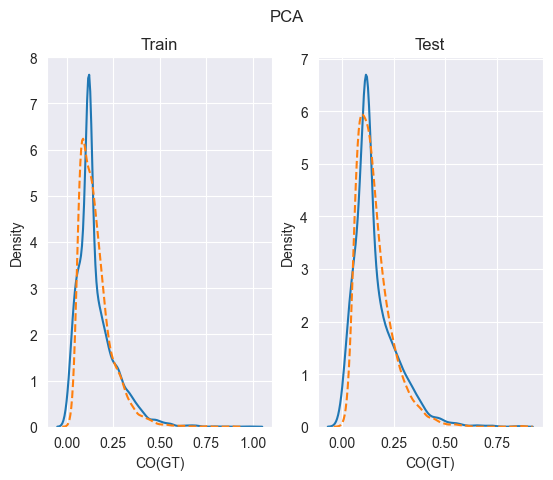

In [97]:
train_prediction = model.predict(X_train_pca)
test_prediction = model.predict(X_test_pca)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("PCA")

C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2320827739.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='lower right')
C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2320827739.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='lower right')
C:\Users\79585\AppData\Local\Temp\ipykernel_7264\2320827739.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='lower right')


Text(0.5, 0.98, 'Сравнение накопленной дисперсии по типам ядер')

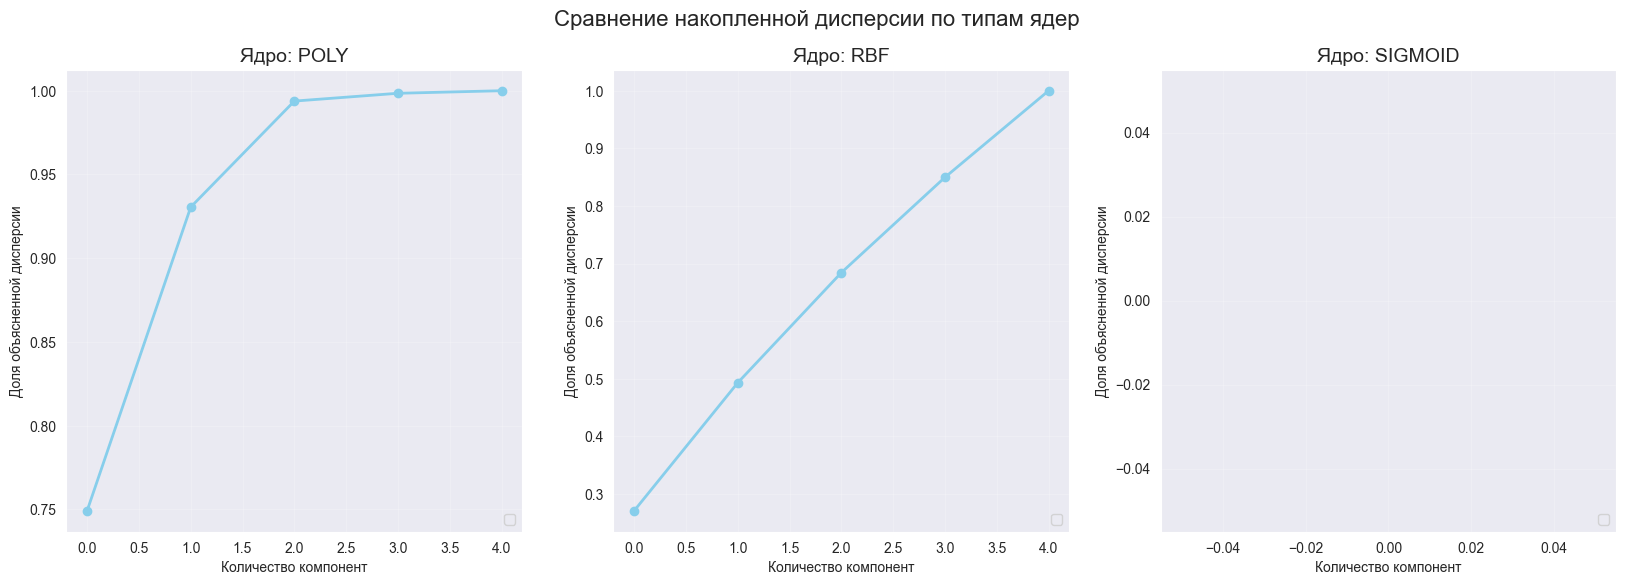

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA

kernels = ['poly', 'rbf', 'sigmoid']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kernel_selector = []
for i, kernel in enumerate(kernels):

    kpca = KernelPCA(kernel=kernel, n_components=5, eigen_solver='dense')
    kpca.fit(X_train)
    kernel_selector.append(kpca)

    if kernel != 'sigmoid':

        X_train_selected = kpca.transform(X_train)
        X_test_selected  = kpca.transform(X_test)
        model = CatBoostRegressor(**best_params)
        model.fit(X_train_selected, y_train)
        input_into_table(X_train_selected, X_test_selected, y_train, y_test, model, name=f"PCA {kernel}")


    ev = kpca.eigenvalues_
    ev = ev[ev > 0]
    ev_ratio = ev / np.sum(ev)
    cumulative_variance = np.cumsum(ev_ratio)


    axes[i].plot(cumulative_variance, color='skyblue', lw=2, marker='o')

    axes[i].set_title(f'Ядро: {kernel.upper()}', fontsize=14)
    axes[i].set_xlabel('Количество компонент')
    axes[i].set_ylabel('Доля объясненной дисперсии')
    axes[i].grid(alpha=0.2)
    axes[i].legend(loc='lower right')

plt.suptitle('Сравнение накопленной дисперсии по типам ядер', fontsize=16)


In [99]:
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252
PCA,0.85,0.0015,0.0392,0.0292,0.79,0.0022,0.0473,0.0336
PCA poly,0.91,0.0009,0.0307,0.0231,0.85,0.0016,0.0400,0.0287
PCA rbf,0.58,0.0044,0.0663,0.0494,0.41,0.0062,0.0790,0.0581


Text(0.5, 0.98, 'PCA polynomial')

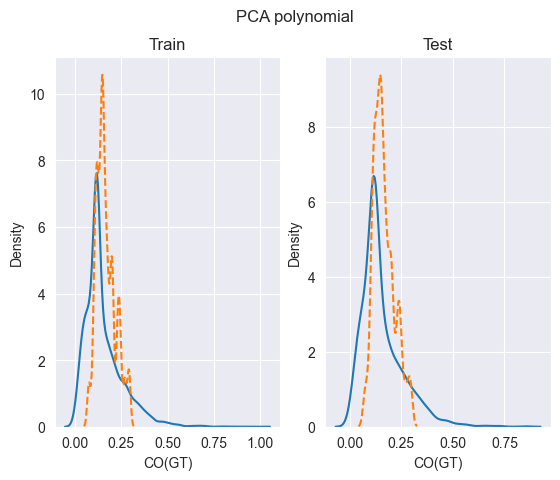

In [100]:
pca_poly = kernel_selector[0]
X_train_poly = pca_poly.transform(X_train)
X_test_poly = pca_poly.transform(X_test)
train_prediction = model.predict(X_train_poly)
test_prediction = model.predict(X_test_poly)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("PCA polynomial")

Text(0.5, 0.98, 'PCA rbf')

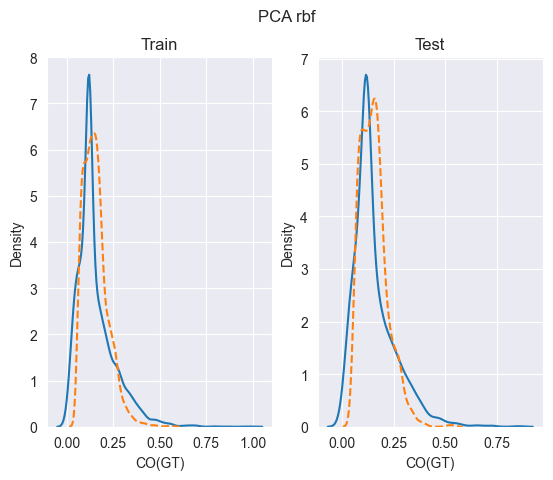

In [101]:
pca_poly = kernel_selector[1]
X_train_poly = pca_poly.transform(X_train)
X_test_poly = pca_poly.transform(X_test)
train_prediction = model.predict(X_train_poly)
test_prediction = model.predict(X_test_poly)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("PCA rbf")

### UMAP

In [102]:
from umap import UMAP

umap = UMAP(n_components=3, random_state=42)
X_umap_train = umap.fit_transform(X_train)
X_umap_test = umap.transform(X_test)

model = CatBoostRegressor(**best_params)
model.fit(X_umap_train, y_train)
input_into_table(X_umap_train, X_umap_test, y_train, y_test, model, name="UMAP")
table

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252
PCA,0.85,0.0015,0.0392,0.0292,0.79,0.0022,0.0473,0.0336
PCA poly,0.91,0.0009,0.0307,0.0231,0.85,0.0016,0.0400,0.0287
PCA rbf,0.58,0.0044,0.0663,0.0494,0.41,0.0062,0.0790,0.0581
UMAP,0.67,0.0035,0.0592,0.0442,0.49,0.0053,0.0728,0.0524


Text(0.5, 0.98, 'UMAP')

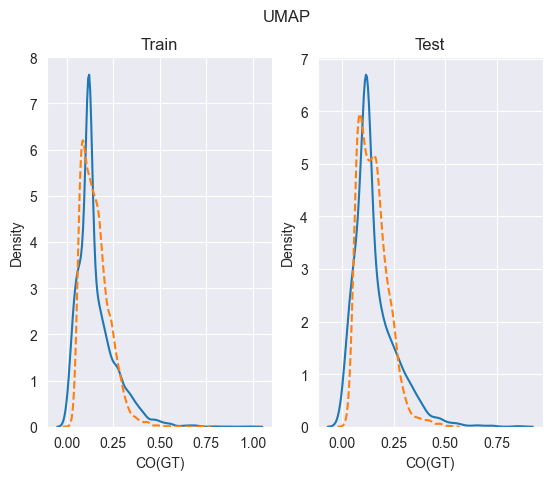

In [103]:
train_prediction = model.predict(X_umap_train)
test_prediction = model.predict(X_umap_test)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("UMAP")

### t-SNE

In [104]:
from sklearn.manifold import TSNE

X_combined = pd.concat([X_train, X_test])

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_combined_tsne = tsne.fit_transform(X_combined)

X_tsne_train = X_combined_tsne[:len(X_train)]
X_tsne_test = X_combined_tsne[len(X_train):]

model = CatBoostRegressor(**best_params)
model.fit(X_tsne_train, y_train)
input_into_table(X_tsne_train, X_tsne_test, y_train, y_test, model, name="t-SNE")

Text(0.5, 0.98, 't-SNE')

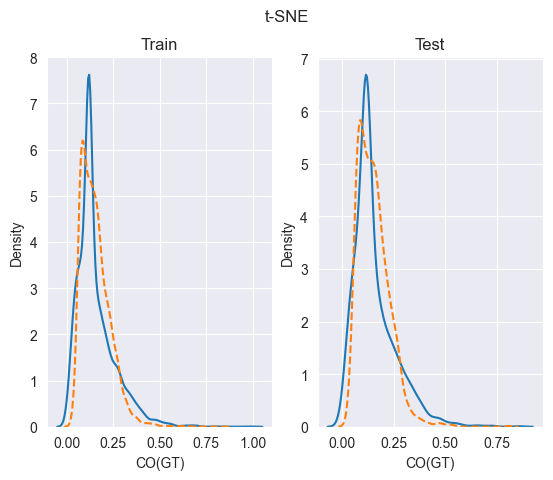

In [105]:
train_prediction = model.predict(X_tsne_train)
test_prediction = model.predict(X_tsne_test)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("t-SNE")

In [106]:
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252
PCA,0.85,0.0015,0.0392,0.0292,0.79,0.0022,0.0473,0.0336
PCA poly,0.91,0.0009,0.0307,0.0231,0.85,0.0016,0.0400,0.0287
PCA rbf,0.58,0.0044,0.0663,0.0494,0.41,0.0062,0.0790,0.0581
UMAP,0.67,0.0035,0.0592,0.0442,0.49,0.0053,0.0728,0.0524
t-SNE,0.70,0.0031,0.0557,0.0419,0.59,0.0043,0.0652,0.0481


### Isomap

In [107]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=3, n_neighbors=10)
X_isomap_train = isomap.fit_transform(X_train)
X_isomap_test = isomap.transform(X_test)

In [108]:
model = CatBoostRegressor(**best_params)
model.fit(X_isomap_train, y_train)
input_into_table(X_isomap_train, X_isomap_test, y_train, y_test, model, name="Isomap")
table

,Train R2,Train MSE,Train RMSE,Train MAE,Test R2,Test MSE,Test RMSE,Test MAE
VarianceThreshold,0.97,0.0003,0.0175,0.0125,0.92,0.0009,0.0292,0.0186
SelectKBest,0.92,0.0009,0.0294,0.0205,0.84,0.0016,0.0405,0.0260
RFE,0.92,0.0009,0.0295,0.0204,0.85,0.0016,0.0397,0.0252
PCA,0.85,0.0015,0.0392,0.0292,0.79,0.0022,0.0473,0.0336
PCA poly,0.91,0.0009,0.0307,0.0231,0.85,0.0016,0.0400,0.0287
PCA rbf,0.58,0.0044,0.0663,0.0494,0.41,0.0062,0.0790,0.0581
UMAP,0.67,0.0035,0.0592,0.0442,0.49,0.0053,0.0728,0.0524
t-SNE,0.70,0.0031,0.0557,0.0419,0.59,0.0043,0.0652,0.0481
Isomap,0.66,0.0036,0.0599,0.0450,0.49,0.0054,0.0735,0.0532


Text(0.5, 0.98, 'Isomap')

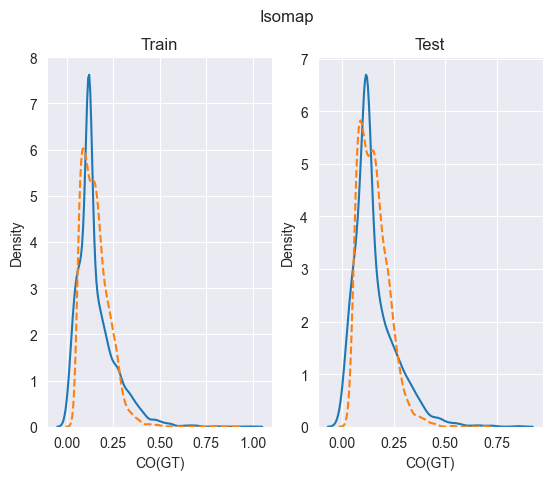

In [109]:
train_prediction = model.predict(X_isomap_train)
test_prediction = model.predict(X_isomap_test)

fig, axes = plt.subplots(1, 2)
sns.kdeplot(y_train, label="Истинные значения", ax=axes[0])
sns.kdeplot(train_prediction, label="Предсказанные значения", ax=axes[0], linestyle="--")
axes[0].set_title("Train")

sns.kdeplot(y_test, label="Истинные значения", ax=axes[1])
sns.kdeplot(test_prediction, label="Предсказанные значения", ax=axes[1], linestyle="--")
axes[1].set_title("Test")

plt.suptitle("Isomap")